# Interacting terms — non-proportional hazards and stratified baselines

Conditional transformation models (CTMs) usually split the dependence of
the response on the covariates into a *baseline* transformation $h_0(y)$
and an additive *shift* $x^\top\beta$:

$$
h(y \mid x) \;=\; h_0(y) + x^\top \beta,
$$

the assumption that yields proportional hazards (`Coxph`),
proportional odds (`Colr`), or a covariate-shifted Gaussian (`BoxCox`).
When that assumption fails — when the *shape* of the conditional
distribution changes with $x$, not just its location — the shift model
is mis-specified.  pymlt's :class:`~pymlt.basis.InteractionBasis`
replaces the additive structure with a tensor product,

$$
h(y \mid x) \;=\; \bigl(a(y) \otimes b(x)\bigr)^{\!\top} \mathrm{vec}(\Theta),
$$

so the transformation itself depends on $x$.  See
[ADR 0001](../adr/0001-tensor-product-interaction-basis.md) for the
parameter-vector layout and monotonicity strategy.

This vignette walks through two canonical uses of that machinery:

1. **Stratified Box-Cox** — different baseline transformations per
   stratum (Bernstein-y $\otimes$ one-hot-x).
2. **Non-proportional Cox** — survival curves that cross under a
   continuous covariate (Bernstein-y $\otimes$ Bernstein-x).

For each example we fit the model, compare it against the proportional
baseline via a likelihood-ratio test, and plot the conditional CDF,
density, survival and hazard.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

import pymlt
from pymlt.basis import BernsteinBasis, OneHotBasis

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## 1. Stratified Box-Cox

We simulate three groups whose conditional distributions disagree both
in location *and* in shape, so the proportional Box-Cox model
($h(y) + x^\top\beta \sim \mathcal{N}(0,1)$) cannot fit them.

* Stratum 0 — $\mathcal{N}(\mu=2,\,\sigma=0.6)$ (sharply peaked).
* Stratum 1 — $\mathcal{N}(\mu=4,\,\sigma=1.2)$ (medium spread).
* Stratum 2 — $\log\mathcal{N}(\mu=1.4,\,\sigma=0.45)$ (right-skewed).

The third stratum is deliberately non-Gaussian — a global Box-Cox would
force a single $h$ to fit all three shapes simultaneously, and the
skewed stratum is the one that pays for the compromise.

In [2]:
n_per = 250
K = 3
stratum = np.repeat(np.arange(K), n_per).astype(float)
y_s0 = rng.normal(loc=2.0, scale=0.6, size=n_per)
y_s1 = rng.normal(loc=4.0, scale=1.2, size=n_per)
y_s2 = rng.lognormal(mean=1.4, sigma=0.45, size=n_per)
y = np.concatenate([y_s0, y_s1, y_s2])

a = float(y.min()) - 0.25
b = float(y.max()) + 0.25
print(f"n={y.size},  support=({a:.2f}, {b:.2f}),  K={K}")

n=750,  support=(-0.93, 12.15),  K=3


### Proportional baseline (shift model)

A standard `BoxCox` with the stratum index entered as a covariate.  This
is the proportional reference model: a single baseline transformation
$h_0$ is shifted by $x^\top\beta$ — it cannot change *shape* between
strata.

In [3]:
X_shift = np.zeros((y.size, K - 1), dtype=float)
for k in range(1, K):
    X_shift[stratum == k, k - 1] = 1.0

shift = pymlt.BoxCox(support=(a, b), order=6).fit(y, X=X_shift)
print(shift.summary())

Model:        BoxCox
Support:      (-0.9293060760652067, 12.146664193459667)
Basis order:  6
Fitted:       Yes
Log-lik:      -1185.7967
AIC:          2389.5935
BIC:          2431.1741
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -1.8205      0.1048   -17.364  1.549e-67
  X2       -1.9785      0.1043   -18.978  2.581e-80


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_45133/2035786181.py:5: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  shift = pymlt.BoxCox(support=(a, b), order=6).fit(y, X=X_shift)


### Fully-interacting model (stratified baseline)

Bernstein-y $\otimes$ one-hot-x: each stratum gets its own baseline
Bernstein coefficients, but they share a degree and a support.  The
column-wise monotonicity constraint guarantees that $h$ is non-decreasing
in $y$ separately within every stratum.

In [4]:
y_basis = BernsteinBasis(order=6, support=(a, b))
x_basis = OneHotBasis(K=K)
ib = pymlt.InteractionBasis(y_basis=y_basis, x_basis=x_basis)

interact = pymlt.ConditionalTransformationModel(
    basis=ib,
    base_distribution="normal",
    censoring=pymlt.CensoringType.NONE,
    optimizer_config=pymlt.OptimizerConfig(random_state=0),
).fit(y, X=stratum.astype(int))
print(interact)

/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_45133/3928575607.py:10: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  ).fit(y, X=stratum.astype(int))


ConditionalTransformationModel(order=6, censoring=NONE, fitted=True, ll=-1118.94)


### Likelihood-ratio test against the shift model

Under $H_0$ (proportional shift) the LR statistic
$2(\ell_{\text{interact}} - \ell_{\text{shift}})$ is asymptotically
$\chi^2$ with df equal to the difference in free parameters.

In [5]:
ll_shift = shift.result_.log_likelihood
ll_full = interact.result_.log_likelihood
df = interact.n_free_params_ - shift.n_free_params_
lr = 2.0 * (ll_full - ll_shift)
p_value = float(chi2.sf(lr, df=df))
print(f"log-lik shift    : {ll_shift:.3f}  (k={shift.n_free_params_})")
print(f"log-lik interact : {ll_full:.3f}  (k={interact.n_free_params_})")
print(f"LR statistic     : {lr:.2f} on {df} df,  p = {p_value:.2e}")

log-lik shift    : -1185.797  (k=9)
log-lik interact : -1118.938  (k=21)
LR statistic     : 133.72 on 12 df,  p = 1.11e-22


### Conditional CDF and density per stratum

The interacting model returns one conditional curve per requested
covariate row.  We evaluate $F(y \mid k)$ and $f(y \mid k)$ over a fine
$y$-grid for $k = 0, 1, 2$ and overlay the empirical CDF / a kernel
density estimate from each stratum for context.

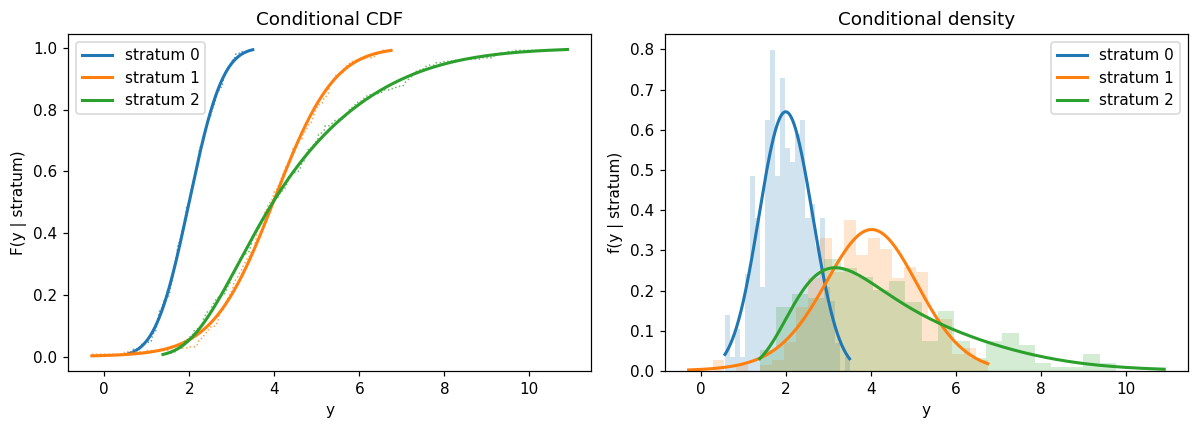

In [6]:
fig, (ax_cdf, ax_pdf) = plt.subplots(1, 2, figsize=(11, 4))

colors = ["C0", "C1", "C2"]
for k in range(K):
    yk = y[stratum == k]
    lo, hi = float(np.quantile(yk, 0.005)), float(np.quantile(yk, 0.995))
    y_grid = np.linspace(lo, hi, 300)
    xk = np.full(y_grid.shape, k, dtype=int)
    cdf_k = interact.predict(y_grid, X_new=xk, what="distribution")
    pdf_k = interact.predict(y_grid, X_new=xk, what="density")

    ecdf = np.searchsorted(np.sort(yk), y_grid, side="right") / yk.size

    ax_cdf.plot(y_grid, cdf_k, color=colors[k], lw=2, label=f"stratum {k}")
    ax_cdf.plot(y_grid, ecdf, color=colors[k], lw=1, ls=":", alpha=0.7)
    ax_pdf.plot(y_grid, pdf_k, color=colors[k], lw=2, label=f"stratum {k}")
    ax_pdf.hist(yk, bins=25, density=True, color=colors[k], alpha=0.2, range=(lo, hi))

ax_cdf.set_xlabel("y"); ax_cdf.set_ylabel("F(y | stratum)")
ax_cdf.set_title("Conditional CDF"); ax_cdf.legend()
ax_pdf.set_xlabel("y"); ax_pdf.set_ylabel("f(y | stratum)")
ax_pdf.set_title("Conditional density"); ax_pdf.legend()
fig.tight_layout();

### Quantile prediction

`predict(..., what="quantile")` inverts $h(\,\cdot\,\mid x)$ row-by-row
on the interaction path — the same grid+spline machinery used for the
non-proportional Cox example below.  The conditional medians track the
Gaussian/lognormal medians of each stratum.

In [7]:
probs = np.array([0.5, 0.5, 0.5])
x_pred = np.array([0, 1, 2], dtype=int)
med_hat = interact.predict(probs, X_new=x_pred, what="quantile")
med_true = np.array([2.0, 4.0, np.exp(1.4)])  # lognormal median = exp(mu)
for k in range(K):
    print(
        f"stratum {k}:  pymlt median = {med_hat[k]:.3f}"
        f"   true median = {med_true[k]:.3f}"
    )

stratum 0:  pymlt median = 1.997   true median = 2.000
stratum 1:  pymlt median = 3.976   true median = 4.000
stratum 2:  pymlt median = 3.969   true median = 4.055


## 2. Non-proportional Cox — crossing survival curves

Now we leave the categorical setting and use a *continuous* covariate.
We simulate survival times whose hazard *shape* depends on $x$: low-$x$
observations have a decreasing hazard (Weibull shape $< 1$, frailty-like
early failure) while high-$x$ observations have an increasing hazard
(Weibull shape $> 1$, ageing).  The medians are similar by construction,
so the survival curves *cross* in the middle of the support — exactly
the textbook violation of the proportional-hazards assumption.

We then fit a non-proportional `Coxph` using
`interacting=BernsteinBasis(...)`, which expands the baseline
log-cumulative-hazard $h$ over both $t$ and $x$ simultaneously.

In [8]:
n_cox = 600
x_cont = rng.uniform(0.0, 1.0, size=n_cox)
shape = 0.8 + 1.4 * x_cont  # 0.8 at x=0  ->  2.2 at x=1
scale = 2.0  # common scale; all S(t | x) curves cross at t = scale
u = rng.uniform(size=n_cox)
t = scale * (-np.log(u)) ** (1.0 / shape)
support_t = (float(t.min()) * 0.5, float(t.max()) + 0.5)
print(f"n={n_cox},  t in [{t.min():.3f}, {t.max():.3f}],  shape in [{shape.min():.2f}, {shape.max():.2f}]")

n=600,  t in [0.004, 13.890],  shape in [0.80, 2.19]


### Proportional baseline

A standard `Coxph` with $x$ as a single-column covariate — the
classical Cox model with a smooth Bernstein baseline.

In [9]:
prop = pymlt.Coxph(support=support_t, order=6).fit(t, X=x_cont.reshape(-1, 1))
print(prop.summary())

Model:        Coxph
Support:      (0.0021859245671776496, 14.389615100396629)
Basis order:  6
Fitted:       Yes
Log-lik:      -1018.6470
AIC:          2053.2939
BIC:          2088.4694
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1        0.4039      0.1459     2.768   0.005632


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_45133/3956983511.py:1: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  prop = pymlt.Coxph(support=support_t, order=6).fit(t, X=x_cont.reshape(-1, 1))


### Non-proportional fit

Passing `interacting=BernsteinBasis(order=q-1, support=(0,1))` routes
the model through the tensor-product likelihood path; the time-basis
stays at order 6 on the original support.  Only exact (non-censored)
times are supported on the interaction path in the current release; the
censoring argument set internally to `RIGHT` is ignored when no
`CensoredData` container is supplied.

In [10]:
x_basis_cox = BernsteinBasis(order=3, support=(0.0, 1.0))
npcox = pymlt.Coxph(
    support=support_t,
    order=6,
    optimizer_config=pymlt.OptimizerConfig(random_state=0),
    interacting=x_basis_cox,
).fit(t, X=x_cont)
ll_prop = prop.result_.log_likelihood
ll_np = npcox.result_.log_likelihood
df = npcox.n_free_params_ - prop.n_free_params_
lr = 2.0 * (ll_np - ll_prop)
p_value = float(chi2.sf(lr, df=df))
print(f"log-lik proportional     : {ll_prop:.3f}  (k={prop.n_free_params_})")
print(f"log-lik non-proportional : {ll_np:.3f}  (k={npcox.n_free_params_})")
print(f"LR statistic             : {lr:.2f} on {df} df,  p = {p_value:.2e}")

/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_45133/1273050889.py:7: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  ).fit(t, X=x_cont)


log-lik proportional     : -1018.647  (k=8)
log-lik non-proportional : -991.968  (k=28)
LR statistic             : 53.36 on 20 df,  p = 7.20e-05


### Crossing survival curves

We evaluate $S(t \mid x)$ for three representative covariate values
($x = 0.1, 0.5, 0.9$), overlay the true Weibull survival, and confirm
visually that the curves cross.

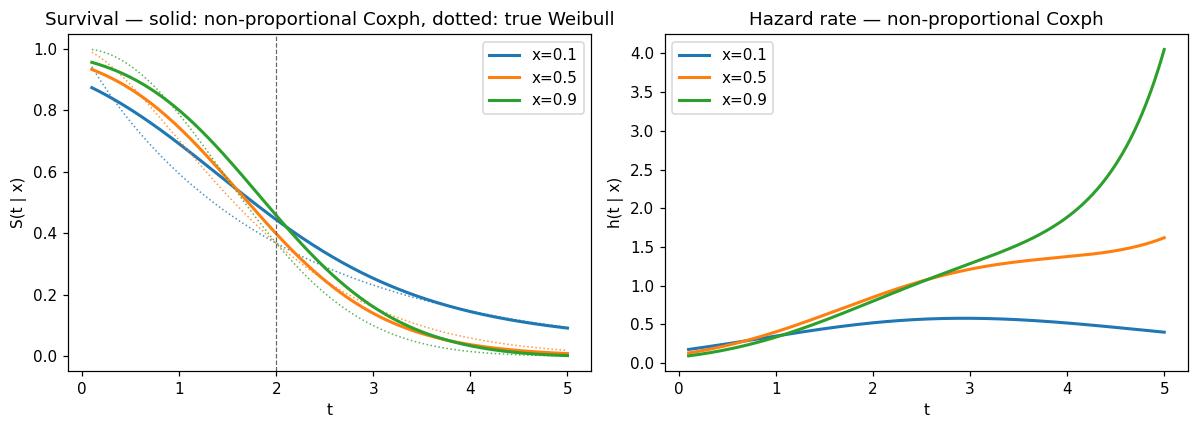

In [11]:
t_grid = np.linspace(0.1, 5.0, 300)
x_reps = np.array([0.1, 0.5, 0.9])
fig, (ax_s, ax_h) = plt.subplots(1, 2, figsize=(11, 4))

for i, xv in enumerate(x_reps):
    xv_grid = np.full_like(t_grid, xv)
    S_np = npcox.survival(t_grid, X=xv_grid)
    h_np = npcox.hazard(t_grid, X=xv_grid)
    shape_v = 0.8 + 1.4 * xv
    S_true = np.exp(-((t_grid / scale) ** shape_v))
    color = f"C{i}"
    ax_s.plot(t_grid, S_np, color=color, lw=2, label=f"x={xv}")
    ax_s.plot(t_grid, S_true, color=color, lw=1, ls=":", alpha=0.8)
    ax_h.plot(t_grid, h_np, color=color, lw=2, label=f"x={xv}")

ax_s.axvline(scale, color="0.4", lw=0.8, ls="--")
ax_s.set_xlabel("t"); ax_s.set_ylabel("S(t | x)")
ax_s.set_title("Survival — solid: non-proportional Coxph, dotted: true Weibull")
ax_s.legend()
ax_h.set_xlabel("t"); ax_h.set_ylabel("h(t | x)")
ax_h.set_title("Hazard rate — non-proportional Coxph")
ax_h.legend()
fig.tight_layout();

### Quantile prediction on the interaction model

`predict(..., what="quantile")` on the non-proportional `Coxph` uses the
row-wise bracket from #67: for each requested probability/$x$ pair the
bracket is derived from the per-row $h(a, x)$ and $h(b, x)$ rather than
the global Bernstein endpoints.  Below we recover the median survival
time at three covariate values.

In [12]:
probs = np.full_like(x_reps, 0.5)
med = npcox.predict(probs, X_new=x_reps, what="quantile")
med_true = scale * (np.log(2.0)) ** (1.0 / (0.8 + 1.4 * x_reps))
for xv, m_hat, m_t in zip(x_reps, med, med_true):
    print(f"x={xv}:  pymlt median = {m_hat:.3f}   true Weibull median = {m_t:.3f}")

x=0.1:  pymlt median = 1.766   true Weibull median = 1.354
x=0.5:  pymlt median = 1.711   true Weibull median = 1.566
x=0.9:  pymlt median = 1.887   true Weibull median = 1.674


## Takeaways

- An :class:`~pymlt.basis.InteractionBasis` replaces the additive shift
  $h_0(y) + x^\top\beta$ with the tensor product
  $(a(y) \otimes b(x))^\top \mathrm{vec}(\Theta)$, letting the *shape*
  of the conditional distribution change with $x$.
- For *stratified* (categorical) covariates the natural x-basis is
  :class:`~pymlt.basis.OneHotBasis`; for *continuous* covariates use
  :class:`~pymlt.basis.BernsteinBasis` (or
  :class:`~pymlt.basis.OrdinalBasis` for ordered categories).  All three
  are non-negative partitions of unity, the condition needed for the
  closed-form column-wise monotonicity constraint.
- The fitted interaction model exposes the standard prediction surface
  (`distribution`, `density`, `survivor`, `hazard`, `quantile`) and
  works with `simulate` and `plot` as documented in
  [ADR 0001](../adr/0001-tensor-product-interaction-basis.md).
- The likelihood-ratio test against the proportional baseline is the
  practical way to decide whether the extra flexibility is justified for
  a given dataset.